# Catastrophic Forgetting in Continual Learning

**ECS7026P — Neural Networks and Deep Learning, Part 2**

This notebook investigates catastrophic forgetting on Split-CIFAR-100 using a small ResNet, comparing five continual learning methods and conducting a buffer-size sweep for Experience Replay.

## Outline

1. Setup and data preparation (Split-CIFAR-100 with 10 tasks of 10 classes each)
2. Model definition (small ResNet adapted for 32×32 inputs)
3. Five methods:
   - **Naive sequential** (lower bound)
   - **Joint training** (upper bound)
   - **Experience Replay** (reservoir-sampled memory buffer)
   - **EWC** (Elastic Weight Consolidation — online variant, Kirkpatrick et al. 2017 / Schwarz et al. 2018)
   - **LwF** (Learning without Forgetting, Li & Hoiem 2017)
4. Continual learning metrics: Average Accuracy (ACC), Backward Transfer (BWT), Forgetting Measure (F)
5. Open-ended experiment: Replay buffer size sweep
6. Plots and analysis

## Notes for execution on Colab T4

- Set runtime to GPU (T4): *Runtime → Change runtime type → T4 GPU*.
- The full notebook runs in roughly 2–3 hours on T4 with the default settings; reduce `EPOCHS_PER_TASK` or `N_SEEDS` if needed.
- All randomness is seeded for reproducibility.
- Per-seed runs are wrapped in try/except so a transient cuDNN failure on one seed will not abort the whole run.


## 1. Setup

In [1]:
# Standard imports
import os
import random
import copy
import json
import time
from collections import defaultdict
from dataclasses import dataclass, field
from typing import List, Dict, Tuple, Optional

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset, ConcatDataset, Dataset
import torchvision
from torchvision import transforms

import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
if device.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))


Device: cuda
GPU: Tesla T4


In [2]:
def set_seed(seed: int):
    """Set all RNG seeds for reproducibility."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = False  # keep cuDNN fast; full determinism is too slow
    torch.backends.cudnn.benchmark = True


## 2. Data: Split-CIFAR-100

CIFAR-100 has 100 classes. We create a *task-incremental* split: 10 sequential tasks, each containing 10 disjoint classes. Within each task, labels are remapped to the range [0, 9] so each task is a 10-way classification problem.

This is the **task-incremental** setting (the task ID is known at test time, so we use a separate classifier head per task). This is the standard easier variant and is appropriate for a project of this scope. The harder *class-incremental* setting (no task ID at test time) is mentioned in the discussion as a limitation.


In [3]:
# CIFAR-100 statistics for normalization
CIFAR100_MEAN = (0.5071, 0.4866, 0.4409)
CIFAR100_STD = (0.2673, 0.2564, 0.2762)

train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(CIFAR100_MEAN, CIFAR100_STD),
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR100_MEAN, CIFAR100_STD),
])

# Download CIFAR-100 (Colab provides /content as workspace)
DATA_ROOT = "./data"
cifar100_train_full = torchvision.datasets.CIFAR100(
    root=DATA_ROOT, train=True, download=True, transform=train_transform
)
cifar100_test_full = torchvision.datasets.CIFAR100(
    root=DATA_ROOT, train=False, download=True, transform=test_transform
)
print(f"Full train: {len(cifar100_train_full)}, full test: {len(cifar100_test_full)}")


100%|██████████| 169M/169M [00:13<00:00, 12.8MB/s] 


Full train: 50000, full test: 10000


In [4]:
# Create the task split. We fix the class assignment to tasks for reproducibility.
N_TASKS = 10
CLASSES_PER_TASK = 10

def make_class_to_task(seed: int = 0) -> List[List[int]]:
    """Return a list of length N_TASKS, where entry t is the list of original
    CIFAR-100 class indices belonging to task t."""
    rng = np.random.RandomState(seed)
    classes = np.arange(100)
    rng.shuffle(classes)
    return [classes[t * CLASSES_PER_TASK:(t + 1) * CLASSES_PER_TASK].tolist()
            for t in range(N_TASKS)]

CLASS_SPLIT = make_class_to_task(seed=0)
for t, cls in enumerate(CLASS_SPLIT):
    print(f"Task {t}: classes {sorted(cls)}")


Task 0: classes [2, 16, 26, 54, 55, 73, 75, 86, 93, 95]
Task 1: classes [7, 8, 13, 22, 24, 30, 33, 53, 78, 92]
Task 2: classes [3, 6, 43, 45, 48, 62, 71, 76, 82, 99]
Task 3: classes [18, 27, 51, 56, 60, 63, 68, 74, 80, 90]
Task 4: classes [1, 4, 5, 15, 17, 38, 40, 41, 42, 61]
Task 5: classes [0, 11, 23, 28, 34, 35, 50, 52, 59, 91]
Task 6: classes [10, 14, 31, 32, 57, 66, 79, 84, 85, 89]
Task 7: classes [19, 20, 29, 49, 69, 72, 77, 94, 97, 98]
Task 8: classes [12, 25, 37, 39, 46, 58, 65, 70, 81, 88]
Task 9: classes [9, 21, 36, 44, 47, 64, 67, 83, 87, 96]


In [5]:
class TaskDataset(Dataset):
    """Wraps a CIFAR-100 dataset and exposes only examples from a given task.
    Labels are remapped to [0, CLASSES_PER_TASK)."""
    def __init__(self, base_dataset, class_list: List[int]):
        self.base = base_dataset
        # Build index of examples in the base dataset whose label is in class_list
        targets = np.array(base_dataset.targets)
        mask = np.isin(targets, class_list)
        self.indices = np.where(mask)[0]
        # Mapping from original class -> new label in [0, CLASSES_PER_TASK)
        self.class_to_local = {c: i for i, c in enumerate(class_list)}

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        x, y = self.base[self.indices[idx]]
        return x, self.class_to_local[y]

# Build per-task train and test datasets
train_tasks = [TaskDataset(cifar100_train_full, CLASS_SPLIT[t]) for t in range(N_TASKS)]
test_tasks = [TaskDataset(cifar100_test_full, CLASS_SPLIT[t]) for t in range(N_TASKS)]
print(f"Per-task sizes -- train: {len(train_tasks[0])}, test: {len(test_tasks[0])}")


Per-task sizes -- train: 5000, test: 1000


## 3. Model: Small ResNet with Multi-Head

We use a small ResNet adapted for 32×32 inputs (similar to the standard "ResNet-18 for CIFAR" variants). For task-incremental learning, the network has a shared backbone and a separate linear classifier head for each task. At test time we use the head corresponding to the task being evaluated.


In [6]:
class BasicBlock(nn.Module):
    """Standard ResNet basic block."""
    expansion = 1
    def __init__(self, in_planes, planes, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_planes, planes, 3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(planes)
        self.conv2 = nn.Conv2d(planes, planes, 3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(planes)
        self.shortcut = nn.Sequential()
        if stride != 1 or in_planes != planes:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_planes, planes, 1, stride=stride, bias=False),
                nn.BatchNorm2d(planes),
            )

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out = out + self.shortcut(x)
        return F.relu(out)

class SmallResNet(nn.Module):
    """ResNet-style backbone for 32x32 images, with one classifier head per task."""
    def __init__(self, n_tasks: int, n_classes_per_task: int, base_width: int = 32):
        super().__init__()
        self.in_planes = base_width
        self.conv1 = nn.Conv2d(3, base_width, 3, stride=1, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(base_width)
        # Three stages, two blocks each
        self.layer1 = self._make_layer(base_width,     2, stride=1)
        self.layer2 = self._make_layer(base_width * 2, 2, stride=2)
        self.layer3 = self._make_layer(base_width * 4, 2, stride=2)
        self.feature_dim = base_width * 4
        # One classifier head per task (task-incremental setting)
        self.heads = nn.ModuleList([
            nn.Linear(self.feature_dim, n_classes_per_task) for _ in range(n_tasks)
        ])

    def _make_layer(self, planes, n_blocks, stride):
        strides = [stride] + [1] * (n_blocks - 1)
        layers = []
        for s in strides:
            layers.append(BasicBlock(self.in_planes, planes, s))
            self.in_planes = planes
        return nn.Sequential(*layers)

    def features(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.layer1(out)
        out = self.layer2(out)
        out = self.layer3(out)
        out = F.adaptive_avg_pool2d(out, 1).flatten(1)
        return out

    def forward(self, x, task_id: int):
        feat = self.features(x)
        return self.heads[task_id](feat)

    def all_logits(self, x):
        """Return logits from every head (used for LwF distillation)."""
        feat = self.features(x)
        return [head(feat) for head in self.heads]

# Sanity check
m = SmallResNet(N_TASKS, CLASSES_PER_TASK).to(device)
n_params = sum(p.numel() for p in m.parameters())
print(f"Model parameters: {n_params:,}")
del m


Model parameters: 708,228


## 4. Training utilities and continual learning metrics

We define:
- A standard per-task training loop
- Evaluation across all seen tasks
- An accuracy matrix R where R[i, j] = test accuracy on task j after training on task i

From R we compute:
- **Average Accuracy (ACC)**: mean of R[N-1, :], the final-row average
- **Backward Transfer (BWT)**: mean over j < N-1 of (R[N-1, j] - R[j, j]) — how much later training affected earlier tasks
- **Forgetting (F)**: mean over j < N-1 of (max_i R[i, j] - R[N-1, j]) — peak-to-final drop per task


In [7]:
@dataclass
class TrainConfig:
    epochs_per_task: int = 5
    batch_size: int = 128
    lr: float = 0.05
    momentum: float = 0.9
    weight_decay: float = 5e-4
    n_workers: int = 2

def evaluate(model, test_dataset, task_id, batch_size=256):
    """Return accuracy on a single task's test set using its dedicated head."""
    model.eval()
    loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False,
                        num_workers=2, pin_memory=True)
    correct, total = 0, 0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)
            logits = model(x, task_id)
            correct += (logits.argmax(1) == y).sum().item()
            total += y.size(0)
    return correct / total

def evaluate_all(model, test_tasks, up_to_task: int):
    """Return a list of accuracies for tasks 0..up_to_task (inclusive)."""
    return [evaluate(model, test_tasks[t], t) for t in range(up_to_task + 1)]

def compute_metrics(R: np.ndarray) -> Dict[str, float]:
    """Compute ACC, BWT, F from an N x N accuracy matrix."""
    N = R.shape[0]
    acc = R[N - 1, :].mean()
    bwt = np.mean([R[N - 1, j] - R[j, j] for j in range(N - 1)])
    forgetting = np.mean([R[:N, j].max() - R[N - 1, j] for j in range(N - 1)])
    return {"ACC": float(acc), "BWT": float(bwt), "F": float(forgetting)}


## 5. Method 1: Naive sequential training (lower bound)

Train on each task sequentially, with no mechanism to preserve past knowledge. This establishes the baseline against which mitigation methods are compared.


In [8]:
def train_one_task_naive(model, task_id, train_dataset, cfg: TrainConfig):
    model.train()
    loader = DataLoader(train_dataset, batch_size=cfg.batch_size, shuffle=True,
                        num_workers=cfg.n_workers, pin_memory=True, drop_last=False)
    optim = torch.optim.SGD(model.parameters(), lr=cfg.lr,
                            momentum=cfg.momentum, weight_decay=cfg.weight_decay)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(optim, T_max=cfg.epochs_per_task)
    losses = []
    for ep in range(cfg.epochs_per_task):
        for x, y in loader:
            x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)
            logits = model(x, task_id)
            loss = F.cross_entropy(logits, y)
            optim.zero_grad()
            loss.backward()
            optim.step()
            losses.append(loss.item())
        sched.step()
    return losses

def run_naive(seed: int, cfg: TrainConfig):
    set_seed(seed)
    model = SmallResNet(N_TASKS, CLASSES_PER_TASK).to(device)
    R = np.zeros((N_TASKS, N_TASKS))
    all_losses = []
    for t in range(N_TASKS):
        losses_t = train_one_task_naive(model, t, train_tasks[t], cfg)
        all_losses.extend(losses_t)
        accs = evaluate_all(model, test_tasks, t)
        for j, a in enumerate(accs):
            R[t, j] = a
        print(f"  [naive seed={seed}] After task {t}: mean acc on seen = {np.mean(accs):.4f}")
    return R, all_losses


## 6. Method 2: Joint training (upper bound)

Train on all tasks' data simultaneously. This is the i.i.d. ceiling — no continual learning method can be expected to exceed it. We construct a combined dataset that yields `(x, y, task_id)` so the right head is used per example.


In [9]:
class JointDataset(Dataset):
    """Concatenates per-task datasets and tags each example with its task id."""
    def __init__(self, task_datasets):
        self.task_datasets = task_datasets
        self.cum_lens = np.cumsum([len(d) for d in task_datasets])

    def __len__(self):
        return int(self.cum_lens[-1])

    def __getitem__(self, idx):
        t = int(np.searchsorted(self.cum_lens, idx, side="right"))
        prev = 0 if t == 0 else self.cum_lens[t - 1]
        x, y = self.task_datasets[t][idx - prev]
        return x, y, t

def run_joint(seed: int, cfg: TrainConfig):
    set_seed(seed)
    model = SmallResNet(N_TASKS, CLASSES_PER_TASK).to(device)
    joint_train = JointDataset(train_tasks)
    # Joint training is given the same total compute budget as sequential (N_TASKS x epochs_per_task)
    n_epochs = cfg.epochs_per_task * N_TASKS
    loader = DataLoader(joint_train, batch_size=cfg.batch_size, shuffle=True,
                        num_workers=cfg.n_workers, pin_memory=True, drop_last=False)
    optim = torch.optim.SGD(model.parameters(), lr=cfg.lr,
                            momentum=cfg.momentum, weight_decay=cfg.weight_decay)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(optim, T_max=n_epochs)
    all_losses = []
    R = np.zeros((N_TASKS, N_TASKS))
    for ep in range(n_epochs):
        model.train()
        for x, y, t_batch in loader:
            x = x.to(device, non_blocking=True)
            y = y.to(device, non_blocking=True)
            t_batch = t_batch.to(device, non_blocking=True)
            # Forward through shared features once, then per-task heads on the relevant indices
            feat = model.features(x)
            loss = 0.0
            n_used = 0
            for t in range(N_TASKS):
                mask = (t_batch == t)
                if mask.any():
                    logits_t = model.heads[t](feat[mask])
                    loss = loss + F.cross_entropy(logits_t, y[mask], reduction="sum")
                    n_used += int(mask.sum().item())
            loss = loss / max(n_used, 1)
            optim.zero_grad()
            loss.backward()
            optim.step()
            all_losses.append(float(loss.item()))
        sched.step()
    # For joint training we only have one "snapshot" so we replicate it across the matrix rows
    # (so metrics like BWT/F are well-defined and trivially zero up to noise).
    final_accs = evaluate_all(model, test_tasks, N_TASKS - 1)
    for i in range(N_TASKS):
        for j in range(N_TASKS):
            R[i, j] = final_accs[j]
    print(f"  [joint seed={seed}] Final mean acc = {np.mean(final_accs):.4f}")
    return R, all_losses


## 7. Method 3: Experience Replay

We maintain a fixed-size memory buffer using **reservoir sampling** (uniform over all examples seen so far, without needing to know stream length in advance). When training on task t, each batch is augmented with a sampled batch from the buffer.

Reservoir sampling keeps the buffer's distribution roughly uniform across all past tasks, which is desirable. We sample replay batches of the same size as the current-task batch.


In [10]:
class ReservoirBuffer:
    """Reservoir sampling buffer storing (image_tensor, label, task_id).
    Stores normalized tensors directly (no augmentation re-applied on retrieval -- a common simplification)."""
    def __init__(self, capacity: int):
        self.capacity = capacity
        self.xs: List[torch.Tensor] = []
        self.ys: List[int] = []
        self.ts: List[int] = []
        self.n_seen = 0

    def add_batch(self, xs: torch.Tensor, ys: torch.Tensor, t: int):
        for i in range(xs.size(0)):
            self.n_seen += 1
            x_cpu = xs[i].detach().cpu()
            y_int = int(ys[i].item())
            if len(self.xs) < self.capacity:
                self.xs.append(x_cpu); self.ys.append(y_int); self.ts.append(t)
            else:
                j = random.randint(0, self.n_seen - 1)
                if j < self.capacity:
                    self.xs[j] = x_cpu; self.ys[j] = y_int; self.ts[j] = t

    def __len__(self):
        return len(self.xs)

    def sample(self, n: int):
        if len(self.xs) == 0:
            return None
        idx = np.random.choice(len(self.xs), size=min(n, len(self.xs)), replace=False)
        xs = torch.stack([self.xs[i] for i in idx]).to(device, non_blocking=True)
        ys = torch.tensor([self.ys[i] for i in idx], dtype=torch.long, device=device)
        ts = torch.tensor([self.ts[i] for i in idx], dtype=torch.long, device=device)
        return xs, ys, ts

def train_one_task_replay(model, task_id, train_dataset, buffer: ReservoirBuffer, cfg: TrainConfig):
    model.train()
    loader = DataLoader(train_dataset, batch_size=cfg.batch_size, shuffle=True,
                        num_workers=cfg.n_workers, pin_memory=True, drop_last=False)
    optim = torch.optim.SGD(model.parameters(), lr=cfg.lr,
                            momentum=cfg.momentum, weight_decay=cfg.weight_decay)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(optim, T_max=cfg.epochs_per_task)
    losses = []
    for ep in range(cfg.epochs_per_task):
        for x, y in loader:
            x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)
            # Current task loss
            logits = model(x, task_id)
            loss_cur = F.cross_entropy(logits, y)
            # Replay loss
            replay = buffer.sample(cfg.batch_size) if len(buffer) > 0 else None
            if replay is not None:
                rx, ry, rt = replay
                feat = model.features(rx)
                replay_loss = 0.0
                n_used = 0
                for t in torch.unique(rt).tolist():
                    mask = (rt == t)
                    if mask.any():
                        logits_t = model.heads[t](feat[mask])
                        replay_loss = replay_loss + F.cross_entropy(logits_t, ry[mask], reduction="sum")
                        n_used += int(mask.sum().item())
                replay_loss = replay_loss / max(n_used, 1)
                loss = loss_cur + replay_loss
            else:
                loss = loss_cur
            optim.zero_grad()
            loss.backward()
            optim.step()
            losses.append(float(loss.item()))
            # Add the current batch into the reservoir AFTER using it
            buffer.add_batch(x, y, task_id)
        sched.step()
    return losses

def run_replay(seed: int, cfg: TrainConfig, buffer_capacity: int):
    set_seed(seed)
    model = SmallResNet(N_TASKS, CLASSES_PER_TASK).to(device)
    buffer = ReservoirBuffer(buffer_capacity)
    R = np.zeros((N_TASKS, N_TASKS))
    all_losses = []
    for t in range(N_TASKS):
        losses_t = train_one_task_replay(model, t, train_tasks[t], buffer, cfg)
        all_losses.extend(losses_t)
        accs = evaluate_all(model, test_tasks, t)
        for j, a in enumerate(accs):
            R[t, j] = a
        print(f"  [replay cap={buffer_capacity} seed={seed}] After task {t}: "
              f"mean acc on seen = {np.mean(accs):.4f}, |buffer|={len(buffer)}")
    return R, all_losses


## 8. Method 4: Elastic Weight Consolidation (EWC) — Online variant

After finishing each task, we estimate the diagonal Fisher information matrix on that task's data — this measures how important each parameter is for the task's predictions. When training a new task we add a quadratic penalty $\lambda \sum_i F_i (\theta_i - \theta_i^*)^2$ that pulls important parameters back toward their previous values.

We use the **online EWC** variant from Schwarz et al. 2018: rather than naively accumulating Fisher matrices (which can grow unboundedly and cause gradient blow-up after many tasks), we apply a decay factor $\gamma$ per task: $F^{accum}_t = \gamma F^{accum}_{t-1} + F_t$. This keeps the regularisation strength bounded and is more numerically stable on long task sequences.

We also apply gradient clipping (max norm 1.0) for additional stability, since the EWC penalty can produce large gradients when parameters drift far from their anchors.

References:
- Kirkpatrick et al. 2017, "Overcoming catastrophic forgetting in neural networks", PNAS.
- Schwarz et al. 2018, "Progress & Compress: A scalable framework for continual learning", ICML.


In [11]:
def compute_fisher(model, task_id, dataset, n_samples: int = 1024, batch_size: int = 64):
    """Estimate diagonal Fisher information using sampled labels."""
    model.eval()
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True, num_workers=2)
    fisher = {n: torch.zeros_like(p) for n, p in model.named_parameters() if p.requires_grad}
    n_used = 0
    for x, y in loader:
        if n_used >= n_samples:
            break
        x = x.to(device, non_blocking=True)
        model.zero_grad()
        logits = model(x, task_id)
        log_probs = F.log_softmax(logits, dim=1)
        with torch.no_grad():
            sampled_y = torch.multinomial(log_probs.exp(), num_samples=1).squeeze(1)
        loss = F.nll_loss(log_probs, sampled_y)
        loss.backward()
        for n, p in model.named_parameters():
            if p.grad is not None:
                fisher[n] += p.grad.detach().pow(2) * x.size(0)
        n_used += x.size(0)
    for n in fisher:
        fisher[n] /= max(n_used, 1)
    model.zero_grad()
    return fisher

def train_one_task_ewc(model, task_id, train_dataset,
                      fisher_accum: Optional[Dict[str, torch.Tensor]],
                      params_anchor: Optional[Dict[str, torch.Tensor]],
                      cfg: TrainConfig, ewc_lambda: float, grad_clip: float = 1.0):
    """Train one task with EWC penalty. Includes gradient clipping for stability."""
    model.train()
    loader = DataLoader(train_dataset, batch_size=cfg.batch_size, shuffle=True,
                        num_workers=cfg.n_workers, pin_memory=True, drop_last=False)
    optim = torch.optim.SGD(model.parameters(), lr=cfg.lr,
                            momentum=cfg.momentum, weight_decay=cfg.weight_decay)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(optim, T_max=cfg.epochs_per_task)
    losses = []
    for ep in range(cfg.epochs_per_task):
        for x, y in loader:
            x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)
            logits = model(x, task_id)
            loss = F.cross_entropy(logits, y)
            if fisher_accum is not None and params_anchor is not None:
                ewc_loss = 0.0
                for n, p in model.named_parameters():
                    if n in fisher_accum:
                        ewc_loss = ewc_loss + (fisher_accum[n] * (p - params_anchor[n]).pow(2)).sum()
                loss = loss + (ewc_lambda / 2) * ewc_loss
            optim.zero_grad()
            loss.backward()
            # Gradient clipping prevents the EWC penalty from causing huge updates
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=grad_clip)
            optim.step()
            losses.append(float(loss.item()))
        sched.step()
    return losses

def run_ewc(seed: int, cfg: TrainConfig, ewc_lambda: float = 400.0, ewc_gamma: float = 0.9):
    """Online EWC: Fisher matrices are accumulated with a decay factor gamma per task,
    so importance does not grow unboundedly across many tasks (Schwarz et al. 2018).
    """
    set_seed(seed)
    model = SmallResNet(N_TASKS, CLASSES_PER_TASK).to(device)
    fisher_accum = None
    params_anchor = None
    R = np.zeros((N_TASKS, N_TASKS))
    all_losses = []
    for t in range(N_TASKS):
        losses_t = train_one_task_ewc(model, t, train_tasks[t],
                                      fisher_accum, params_anchor, cfg, ewc_lambda)
        all_losses.extend(losses_t)
        # Compute Fisher on data from the just-finished task
        new_fisher = compute_fisher(model, t, train_tasks[t])
        if fisher_accum is None:
            fisher_accum = new_fisher
        else:
            # Online EWC: decay old Fisher and add new one
            fisher_accum = {n: ewc_gamma * fisher_accum[n] + new_fisher[n] for n in fisher_accum}
        params_anchor = {n: p.detach().clone() for n, p in model.named_parameters()}
        accs = evaluate_all(model, test_tasks, t)
        for j, a in enumerate(accs):
            R[t, j] = a
        print(f"  [ewc lambda={ewc_lambda} gamma={ewc_gamma} seed={seed}] "
              f"After task {t}: mean acc = {np.mean(accs):.4f}")
    return R, all_losses


## 9. Method 5: Learning without Forgetting (LwF)

Before training on a new task, snapshot the model. During new-task training, we add a knowledge distillation loss: for each previous task's head, compute the new model's logits on current-task inputs, and match them to the *frozen old model's* logits via temperature-softened cross-entropy.

This requires no replay buffer — only a copy of the previous model. The implicit assumption is that current-task inputs are informative for preserving previous tasks' decision boundaries (which is approximately true when domains are similar).

Reference: Li & Hoiem 2017, "Learning without Forgetting", TPAMI.


In [12]:
def distillation_loss(student_logits, teacher_logits, T: float = 2.0):
    """Soft cross-entropy with temperature, summed over outputs and averaged over batch."""
    s = F.log_softmax(student_logits / T, dim=1)
    t = F.softmax(teacher_logits / T, dim=1)
    return -(t * s).sum(dim=1).mean() * (T * T)

def train_one_task_lwf(model, task_id, train_dataset,
                      teacher: Optional[nn.Module], cfg: TrainConfig,
                      lwf_alpha: float, lwf_T: float):
    model.train()
    if teacher is not None:
        teacher.eval()
        for p in teacher.parameters():
            p.requires_grad = False
    loader = DataLoader(train_dataset, batch_size=cfg.batch_size, shuffle=True,
                        num_workers=cfg.n_workers, pin_memory=True, drop_last=False)
    optim = torch.optim.SGD(model.parameters(), lr=cfg.lr,
                            momentum=cfg.momentum, weight_decay=cfg.weight_decay)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(optim, T_max=cfg.epochs_per_task)
    losses = []
    for ep in range(cfg.epochs_per_task):
        for x, y in loader:
            x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)
            logits_cur = model(x, task_id)
            loss = F.cross_entropy(logits_cur, y)
            if teacher is not None and task_id > 0:
                # Distill old heads' outputs on current data
                with torch.no_grad():
                    teacher_feat = teacher.features(x)
                student_feat = model.features(x)
                distill = 0.0
                for t_old in range(task_id):
                    teacher_logits = teacher.heads[t_old](teacher_feat)
                    student_logits = model.heads[t_old](student_feat)
                    distill = distill + distillation_loss(student_logits, teacher_logits, T=lwf_T)
                distill = distill / task_id
                loss = loss + lwf_alpha * distill
            optim.zero_grad()
            loss.backward()
            optim.step()
            losses.append(float(loss.item()))
        sched.step()
    return losses

def run_lwf(seed: int, cfg: TrainConfig, lwf_alpha: float = 1.0, lwf_T: float = 2.0):
    set_seed(seed)
    model = SmallResNet(N_TASKS, CLASSES_PER_TASK).to(device)
    teacher = None
    R = np.zeros((N_TASKS, N_TASKS))
    all_losses = []
    for t in range(N_TASKS):
        losses_t = train_one_task_lwf(model, t, train_tasks[t], teacher, cfg, lwf_alpha, lwf_T)
        all_losses.extend(losses_t)
        # Snapshot the model AFTER training task t for use as teacher next task
        teacher = copy.deepcopy(model).to(device)
        teacher.eval()
        accs = evaluate_all(model, test_tasks, t)
        for j, a in enumerate(accs):
            R[t, j] = a
        print(f"  [lwf alpha={lwf_alpha} seed={seed}] After task {t}: mean acc = {np.mean(accs):.4f}")
    return R, all_losses


## 10. Main experiment: comparing all five methods

We run each method with **3 seeds** to estimate variance. Default settings below are calibrated for a T4 GPU run. To shrink runtime drastically (for debugging), set `EPOCHS_PER_TASK = 2` and `N_SEEDS = 1`.

Approximate timings per seed on T4:
- Naive: ~6 min
- Replay (cap=2000): ~7 min
- EWC: ~7 min
- LwF: ~8 min
- Joint: ~6 min

So all 5 methods × 3 seeds is roughly ~100 minutes. The buffer sweep that follows adds another ~50 minutes.


In [13]:
# Configuration knobs (edit these to control runtime)
EPOCHS_PER_TASK = 5
N_SEEDS = 3
SEEDS = [0, 1, 2][:N_SEEDS]

cfg = TrainConfig(epochs_per_task=EPOCHS_PER_TASK)

# Results container: results[method_name] = list of (R, losses) tuples, one per seed
results: Dict[str, List[Tuple[np.ndarray, List[float]]]] = defaultdict(list)


In [14]:
# Run Naive
print("\n=== NAIVE ===")
for s in SEEDS:
    t0 = time.time()
    try:
        R, losses = run_naive(s, cfg)
        print(f"  seed {s} done in {time.time()-t0:.0f}s, metrics={compute_metrics(R)}")
        results["Naive"].append((R, losses))
    except RuntimeError as e:
        print(f"  seed {s} FAILED with RuntimeError: {e}")
    finally:
        if torch.cuda.is_available():
            torch.cuda.empty_cache()



=== NAIVE ===
  [naive seed=0] After task 0: mean acc on seen = 0.4830
  [naive seed=0] After task 1: mean acc on seen = 0.4450
  [naive seed=0] After task 2: mean acc on seen = 0.3957
  [naive seed=0] After task 3: mean acc on seen = 0.3528
  [naive seed=0] After task 4: mean acc on seen = 0.3826
  [naive seed=0] After task 5: mean acc on seen = 0.3892
  [naive seed=0] After task 6: mean acc on seen = 0.3707
  [naive seed=0] After task 7: mean acc on seen = 0.3260
  [naive seed=0] After task 8: mean acc on seen = 0.3331
  [naive seed=0] After task 9: mean acc on seen = 0.3370
  seed 0 done in 130s, metrics={'ACC': 0.337, 'BWT': -0.32555555555555554, 'F': 0.32555555555555554}
  [naive seed=1] After task 0: mean acc on seen = 0.5120
  [naive seed=1] After task 1: mean acc on seen = 0.4740
  [naive seed=1] After task 2: mean acc on seen = 0.4597
  [naive seed=1] After task 3: mean acc on seen = 0.4078
  [naive seed=1] After task 4: mean acc on seen = 0.3944
  [naive seed=1] After task 5

In [15]:
# Run Joint (upper bound)
print("\n=== JOINT ===")
for s in SEEDS:
    t0 = time.time()
    try:
        R, losses = run_joint(s, cfg)
        print(f"  seed {s} done in {time.time()-t0:.0f}s, metrics={compute_metrics(R)}")
        results["Joint"].append((R, losses))
    except RuntimeError as e:
        print(f"  seed {s} FAILED with RuntimeError: {e}")
    finally:
        if torch.cuda.is_available():
            torch.cuda.empty_cache()



=== JOINT ===
  [joint seed=0] Final mean acc = 0.8951
  seed 0 done in 1224s, metrics={'ACC': 0.8950999999999999, 'BWT': 0.0, 'F': 0.0}
  [joint seed=1] Final mean acc = 0.8980
  seed 1 done in 1216s, metrics={'ACC': 0.898, 'BWT': 0.0, 'F': 0.0}
  [joint seed=2] Final mean acc = 0.8973
  seed 2 done in 1197s, metrics={'ACC': 0.8973000000000001, 'BWT': 0.0, 'F': 0.0}


In [16]:
# Run Replay with default capacity (used as the main "Replay" entry in comparison)
DEFAULT_REPLAY_CAPACITY = 2000
print(f"\n=== REPLAY (capacity={DEFAULT_REPLAY_CAPACITY}) ===")
for s in SEEDS:
    t0 = time.time()
    try:
        R, losses = run_replay(s, cfg, buffer_capacity=DEFAULT_REPLAY_CAPACITY)
        print(f"  seed {s} done in {time.time()-t0:.0f}s, metrics={compute_metrics(R)}")
        results["Replay-2000"].append((R, losses))
    except RuntimeError as e:
        print(f"  seed {s} FAILED with RuntimeError: {e}")
    finally:
        if torch.cuda.is_available():
            torch.cuda.empty_cache()



=== REPLAY (capacity=2000) ===
  [replay cap=2000 seed=0] After task 0: mean acc on seen = 0.5460, |buffer|=2000
  [replay cap=2000 seed=0] After task 1: mean acc on seen = 0.5610, |buffer|=2000
  [replay cap=2000 seed=0] After task 2: mean acc on seen = 0.6357, |buffer|=2000
  [replay cap=2000 seed=0] After task 3: mean acc on seen = 0.6462, |buffer|=2000
  [replay cap=2000 seed=0] After task 4: mean acc on seen = 0.6436, |buffer|=2000
  [replay cap=2000 seed=0] After task 5: mean acc on seen = 0.6555, |buffer|=2000
  [replay cap=2000 seed=0] After task 6: mean acc on seen = 0.6686, |buffer|=2000
  [replay cap=2000 seed=0] After task 7: mean acc on seen = 0.6645, |buffer|=2000
  [replay cap=2000 seed=0] After task 8: mean acc on seen = 0.6614, |buffer|=2000
  [replay cap=2000 seed=0] After task 9: mean acc on seen = 0.6742, |buffer|=2000
  seed 0 done in 195s, metrics={'ACC': 0.6742, 'BWT': -0.046000000000000006, 'F': 0.05544444444444444}
  [replay cap=2000 seed=1] After task 0: mean

In [17]:
# Run EWC (online variant with decay)
print("\n=== EWC ===")
EWC_LAMBDA = 400.0
EWC_GAMMA = 0.9
for s in SEEDS:
    t0 = time.time()
    try:
        R, losses = run_ewc(s, cfg, ewc_lambda=EWC_LAMBDA, ewc_gamma=EWC_GAMMA)
        print(f"  seed {s} done in {time.time()-t0:.0f}s, metrics={compute_metrics(R)}")
        results["EWC"].append((R, losses))
    except RuntimeError as e:
        print(f"  seed {s} FAILED with RuntimeError: {e}")
        print("  Skipping this seed. Try restarting the runtime if this persists.")
    finally:
        if torch.cuda.is_available():
            torch.cuda.empty_cache()



=== EWC ===
  [ewc lambda=400.0 gamma=0.9 seed=0] After task 0: mean acc = 0.5500
  [ewc lambda=400.0 gamma=0.9 seed=0] After task 1: mean acc = 0.5555
  [ewc lambda=400.0 gamma=0.9 seed=0] After task 2: mean acc = 0.5277
  [ewc lambda=400.0 gamma=0.9 seed=0] After task 3: mean acc = 0.4607
  [ewc lambda=400.0 gamma=0.9 seed=0] After task 4: mean acc = 0.4370
  [ewc lambda=400.0 gamma=0.9 seed=0] After task 5: mean acc = 0.4463
  [ewc lambda=400.0 gamma=0.9 seed=0] After task 6: mean acc = 0.4020
  [ewc lambda=400.0 gamma=0.9 seed=0] After task 7: mean acc = 0.4049
  [ewc lambda=400.0 gamma=0.9 seed=0] After task 8: mean acc = 0.3783
  [ewc lambda=400.0 gamma=0.9 seed=0] After task 9: mean acc = 0.4272
  seed 0 done in 162s, metrics={'ACC': 0.4271999999999999, 'BWT': -0.28144444444444444, 'F': 0.28144444444444444}
  [ewc lambda=400.0 gamma=0.9 seed=1] After task 0: mean acc = 0.5560
  [ewc lambda=400.0 gamma=0.9 seed=1] After task 1: mean acc = 0.5080
  [ewc lambda=400.0 gamma=0.9 see

In [18]:
# Run LwF
print("\n=== LwF ===")
LWF_ALPHA = 1.0
LWF_T = 2.0
for s in SEEDS:
    t0 = time.time()
    try:
        R, losses = run_lwf(s, cfg, lwf_alpha=LWF_ALPHA, lwf_T=LWF_T)
        print(f"  seed {s} done in {time.time()-t0:.0f}s, metrics={compute_metrics(R)}")
        results["LwF"].append((R, losses))
    except RuntimeError as e:
        print(f"  seed {s} FAILED with RuntimeError: {e}")
    finally:
        if torch.cuda.is_available():
            torch.cuda.empty_cache()



=== LwF ===
  [lwf alpha=1.0 seed=0] After task 0: mean acc = 0.5030
  [lwf alpha=1.0 seed=0] After task 1: mean acc = 0.4990
  [lwf alpha=1.0 seed=0] After task 2: mean acc = 0.5520
  [lwf alpha=1.0 seed=0] After task 3: mean acc = 0.5428
  [lwf alpha=1.0 seed=0] After task 4: mean acc = 0.5448
  [lwf alpha=1.0 seed=0] After task 5: mean acc = 0.5525
  [lwf alpha=1.0 seed=0] After task 6: mean acc = 0.5364
  [lwf alpha=1.0 seed=0] After task 7: mean acc = 0.5326
  [lwf alpha=1.0 seed=0] After task 8: mean acc = 0.5446
  [lwf alpha=1.0 seed=0] After task 9: mean acc = 0.5328
  seed 0 done in 180s, metrics={'ACC': 0.5328000000000002, 'BWT': -0.11922222222222222, 'F': 0.12177777777777773}
  [lwf alpha=1.0 seed=1] After task 0: mean acc = 0.5010
  [lwf alpha=1.0 seed=1] After task 1: mean acc = 0.5340
  [lwf alpha=1.0 seed=1] After task 2: mean acc = 0.5853
  [lwf alpha=1.0 seed=1] After task 3: mean acc = 0.5742
  [lwf alpha=1.0 seed=1] After task 4: mean acc = 0.5734
  [lwf alpha=1.0 s

## 11. Aggregate metrics and plots for the main comparison

In [19]:
def aggregate(method_results):
    """Given a list of (R, losses) tuples, return mean and std of ACC, BWT, F."""
    metrics_list = [compute_metrics(R) for R, _ in method_results]
    summary = {}
    for k in ["ACC", "BWT", "F"]:
        vals = [m[k] for m in metrics_list]
        summary[k + "_mean"] = float(np.mean(vals))
        summary[k + "_std"] = float(np.std(vals, ddof=0))
    return summary

print(f"{'Method':<14} {'ACC':>14} {'BWT':>14} {'F':>14}")
print("-" * 60)
summary_table = {}
for method, runs in results.items():
    s = aggregate(runs)
    summary_table[method] = s
    print(f"{method:<14} {s['ACC_mean']:.3f} ± {s['ACC_std']:.3f}  "
          f"{s['BWT_mean']:+.3f} ± {s['BWT_std']:.3f}  "
          f"{s['F_mean']:.3f} ± {s['F_std']:.3f}")


Method                    ACC            BWT              F
------------------------------------------------------------
Naive          0.344 ± 0.014  -0.351 ± 0.027  0.351 ± 0.027
Joint          0.897 ± 0.001  +0.000 ± 0.000  0.000 ± 0.000
Replay-2000    0.678 ± 0.004  -0.045 ± 0.004  0.056 ± 0.003
EWC            0.385 ± 0.031  -0.321 ± 0.030  0.321 ± 0.030
LwF            0.530 ± 0.005  -0.147 ± 0.020  0.148 ± 0.019


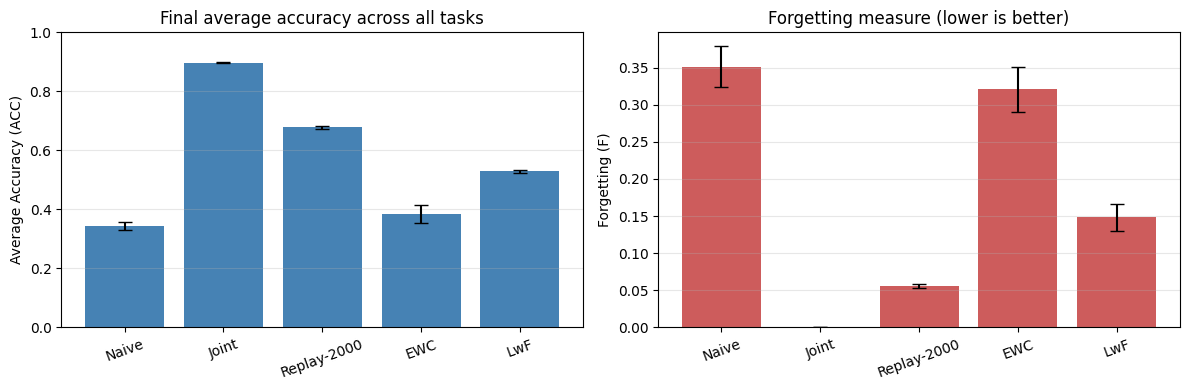

In [20]:
# Plot 1: bar chart of ACC and F per method
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
methods = list(results.keys())
acc_means = [summary_table[m]["ACC_mean"] for m in methods]
acc_stds = [summary_table[m]["ACC_std"] for m in methods]
f_means = [summary_table[m]["F_mean"] for m in methods]
f_stds = [summary_table[m]["F_std"] for m in methods]

axes[0].bar(methods, acc_means, yerr=acc_stds, capsize=5, color="steelblue")
axes[0].set_ylabel("Average Accuracy (ACC)")
axes[0].set_title("Final average accuracy across all tasks")
axes[0].set_ylim(0, 1.0)
axes[0].grid(axis="y", alpha=0.3)

axes[1].bar(methods, f_means, yerr=f_stds, capsize=5, color="indianred")
axes[1].set_ylabel("Forgetting (F)")
axes[1].set_title("Forgetting measure (lower is better)")
axes[1].grid(axis="y", alpha=0.3)

for ax in axes:
    ax.tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.savefig("main_comparison_bars.png", dpi=120, bbox_inches="tight")
plt.show()


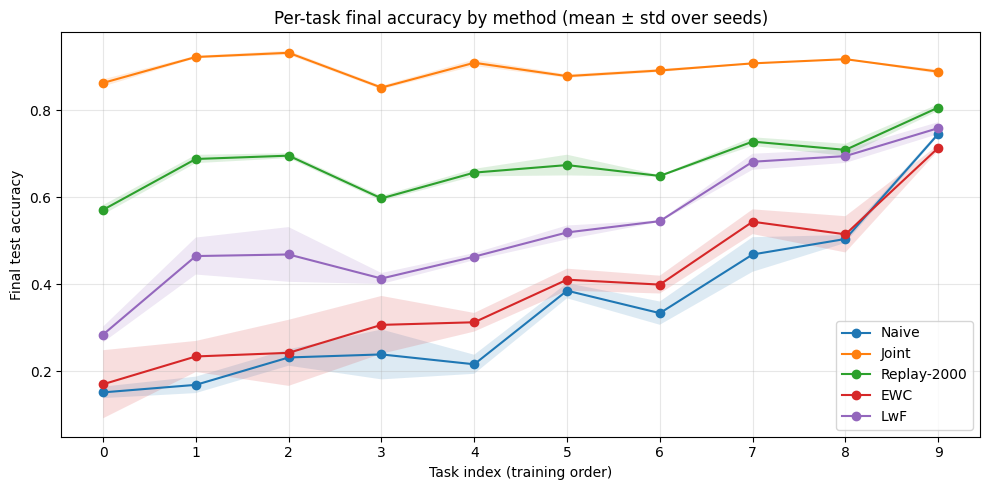

In [21]:
# Plot 2: per-task accuracy at the end of training, averaged over seeds
fig, ax = plt.subplots(figsize=(10, 5))
for method, runs in results.items():
    per_task_final = np.stack([R[N_TASKS - 1, :] for R, _ in runs])  # (n_seeds, N_TASKS)
    mean = per_task_final.mean(axis=0)
    std = per_task_final.std(axis=0)
    ax.plot(range(N_TASKS), mean, marker="o", label=method)
    ax.fill_between(range(N_TASKS), mean - std, mean + std, alpha=0.15)
ax.set_xlabel("Task index (training order)")
ax.set_ylabel("Final test accuracy")
ax.set_title("Per-task final accuracy by method (mean ± std over seeds)")
ax.set_xticks(range(N_TASKS))
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("per_task_final.png", dpi=120, bbox_inches="tight")
plt.show()


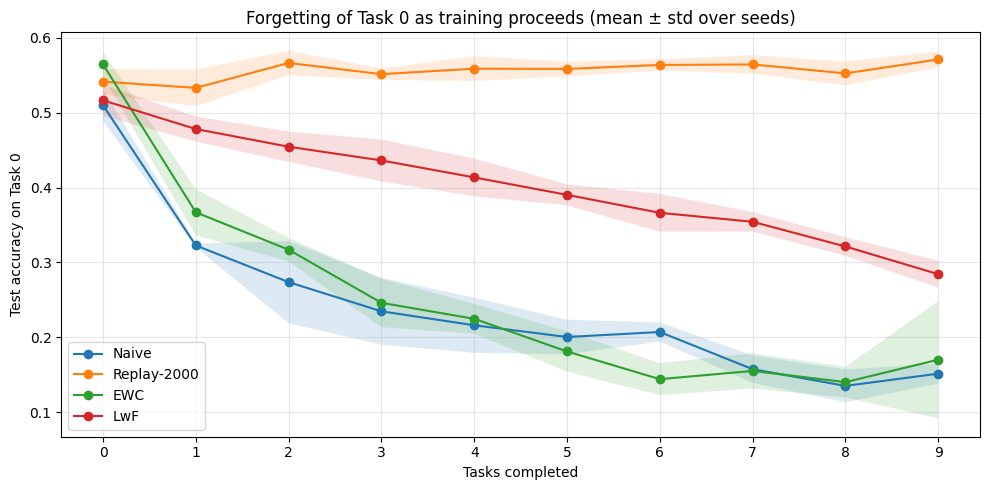

In [22]:
# Plot 3: accuracy on Task 0 over time (the "forgetting curve")
fig, ax = plt.subplots(figsize=(10, 5))
for method, runs in results.items():
    if method == "Joint":
        continue  # Joint trains all at once; the curve is degenerate
    task0_curves = np.stack([R[:, 0] for R, _ in runs])  # (n_seeds, N_TASKS)
    mean = task0_curves.mean(axis=0)
    std = task0_curves.std(axis=0)
    ax.plot(range(N_TASKS), mean, marker="o", label=method)
    ax.fill_between(range(N_TASKS), mean - std, mean + std, alpha=0.15)
ax.set_xlabel("Tasks completed")
ax.set_ylabel("Test accuracy on Task 0")
ax.set_title("Forgetting of Task 0 as training proceeds (mean ± std over seeds)")
ax.set_xticks(range(N_TASKS))
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("task0_forgetting.png", dpi=120, bbox_inches="tight")
plt.show()


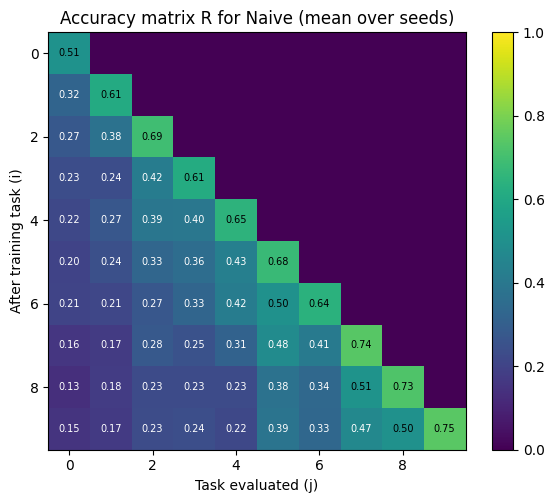

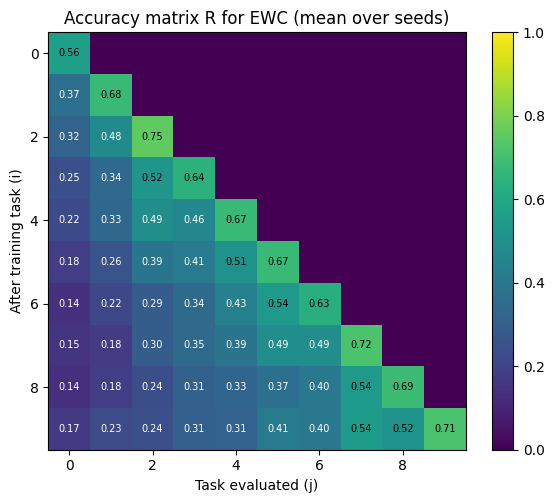

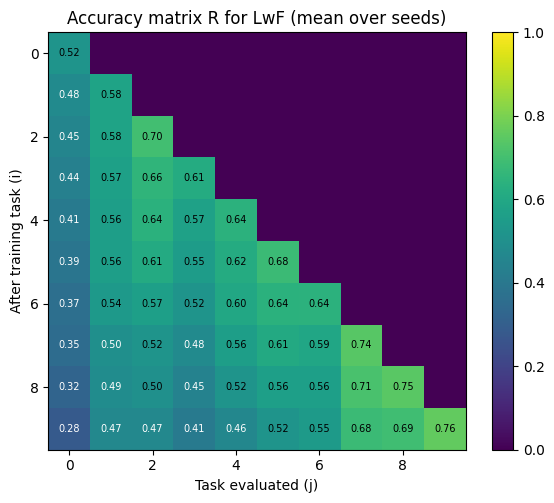

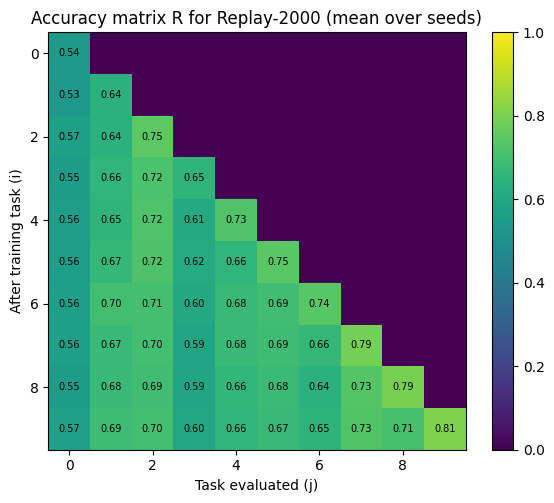

In [23]:
# Plot 4: heatmap of accuracy matrix R for a single method (mean over seeds)
def plot_R_heatmap(method, save_name):
    R_mean = np.mean([R for R, _ in results[method]], axis=0)
    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(R_mean, vmin=0, vmax=1, cmap="viridis")
    ax.set_xlabel("Task evaluated (j)")
    ax.set_ylabel("After training task (i)")
    ax.set_title(f"Accuracy matrix R for {method} (mean over seeds)")
    plt.colorbar(im, ax=ax)
    for i in range(R_mean.shape[0]):
        for j in range(R_mean.shape[1]):
            if j <= i:
                ax.text(j, i, f"{R_mean[i, j]:.2f}", ha="center", va="center",
                        color="white" if R_mean[i, j] < 0.5 else "black", fontsize=7)
    plt.tight_layout()
    plt.savefig(save_name, dpi=120, bbox_inches="tight")
    plt.show()

for m in ["Naive", "EWC", "LwF", "Replay-2000"]:
    if m in results:
        plot_R_heatmap(m, f"R_heatmap_{m}.png")


## 12. Open-ended experiment: replay buffer size sweep

We sweep the buffer capacity for Experience Replay across a logarithmic range and observe how ACC and F change. We also include EWC (no buffer, but a regularisation hyperparameter) and Naive at fixed settings as reference lines.

**Hypotheses to test:**
1. **Diminishing returns**: ACC will plateau as buffer size grows toward the size of the per-task training set (5000 examples).
2. **Threshold effect**: There may be a minimum buffer size below which Replay does not meaningfully exceed Naive (because too few past examples get sampled per batch to provide signal).
3. **EWC vs. small Replay**: EWC, which uses no memory, should outperform Replay with very small buffers but be matched by Replay once the buffer is large enough.


In [24]:
# Buffer capacities to sweep. Per-task train set is 5000, so we go up to ~one full task.
BUFFER_CAPACITIES = [50, 200, 500, 1000, 2000, 5000]
N_SEEDS_SWEEP = 2  # reduce to fit time budget; raise to 3 if you have headroom
SEEDS_SWEEP = SEEDS[:N_SEEDS_SWEEP]

sweep_results: Dict[int, List[Tuple[np.ndarray, List[float]]]] = defaultdict(list)

for cap in BUFFER_CAPACITIES:
    print(f"\n=== REPLAY sweep, capacity = {cap} ===")
    # If we already ran this capacity in the main comparison, reuse it
    if cap == DEFAULT_REPLAY_CAPACITY and "Replay-2000" in results and len(results["Replay-2000"]) >= N_SEEDS_SWEEP:
        sweep_results[cap] = results["Replay-2000"][:N_SEEDS_SWEEP]
        continue
    for s in SEEDS_SWEEP:
        t0 = time.time()
        try:
            R, losses = run_replay(s, cfg, buffer_capacity=cap)
            print(f"  seed {s} done in {time.time()-t0:.0f}s, metrics={compute_metrics(R)}")
            sweep_results[cap].append((R, losses))
        except RuntimeError as e:
            print(f"  seed {s} FAILED with RuntimeError: {e}")
        finally:
            if torch.cuda.is_available():
                torch.cuda.empty_cache()



=== REPLAY sweep, capacity = 50 ===
  [replay cap=50 seed=0] After task 0: mean acc on seen = 0.4750, |buffer|=50
  [replay cap=50 seed=0] After task 1: mean acc on seen = 0.4765, |buffer|=50
  [replay cap=50 seed=0] After task 2: mean acc on seen = 0.4937, |buffer|=50
  [replay cap=50 seed=0] After task 3: mean acc on seen = 0.4507, |buffer|=50
  [replay cap=50 seed=0] After task 4: mean acc on seen = 0.4294, |buffer|=50
  [replay cap=50 seed=0] After task 5: mean acc on seen = 0.3762, |buffer|=50
  [replay cap=50 seed=0] After task 6: mean acc on seen = 0.3894, |buffer|=50
  [replay cap=50 seed=0] After task 7: mean acc on seen = 0.3765, |buffer|=50
  [replay cap=50 seed=0] After task 8: mean acc on seen = 0.3799, |buffer|=50
  [replay cap=50 seed=0] After task 9: mean acc on seen = 0.3775, |buffer|=50
  seed 0 done in 170s, metrics={'ACC': 0.37750000000000006, 'BWT': -0.3331111111111111, 'F': 0.3331111111111111}
  [replay cap=50 seed=1] After task 0: mean acc on seen = 0.5090, |buf

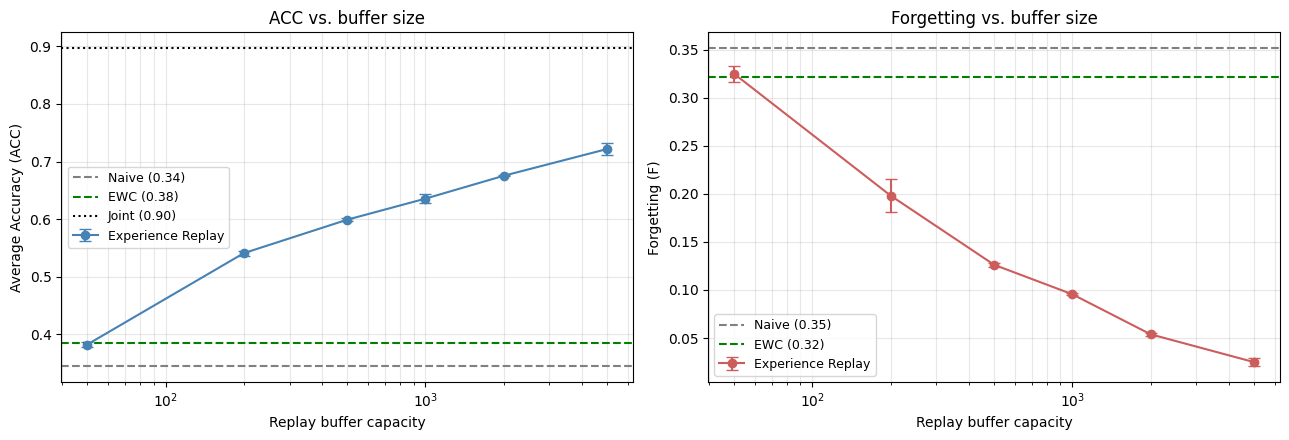

In [25]:
# Plot the sweep
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
caps = sorted(sweep_results.keys())

acc_means, acc_stds, f_means, f_stds = [], [], [], []
for c in caps:
    metrics = [compute_metrics(R) for R, _ in sweep_results[c]]
    acc_means.append(np.mean([m["ACC"] for m in metrics]))
    acc_stds.append(np.std([m["ACC"] for m in metrics]))
    f_means.append(np.mean([m["F"] for m in metrics]))
    f_stds.append(np.std([m["F"] for m in metrics]))

acc_means = np.array(acc_means); acc_stds = np.array(acc_stds)
f_means = np.array(f_means); f_stds = np.array(f_stds)

axes[0].errorbar(caps, acc_means, yerr=acc_stds, marker="o", capsize=4,
                 label="Experience Replay", color="steelblue")
# Reference lines
naive_acc = summary_table["Naive"]["ACC_mean"]
ewc_acc = summary_table["EWC"]["ACC_mean"]
joint_acc = summary_table["Joint"]["ACC_mean"]
axes[0].axhline(naive_acc, color="gray", linestyle="--", label=f"Naive ({naive_acc:.2f})")
axes[0].axhline(ewc_acc, color="green", linestyle="--", label=f"EWC ({ewc_acc:.2f})")
axes[0].axhline(joint_acc, color="black", linestyle=":", label=f"Joint ({joint_acc:.2f})")
axes[0].set_xscale("log")
axes[0].set_xlabel("Replay buffer capacity")
axes[0].set_ylabel("Average Accuracy (ACC)")
axes[0].set_title("ACC vs. buffer size")
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.3, which="both")

axes[1].errorbar(caps, f_means, yerr=f_stds, marker="o", capsize=4,
                 label="Experience Replay", color="indianred")
naive_f = summary_table["Naive"]["F_mean"]
ewc_f = summary_table["EWC"]["F_mean"]
axes[1].axhline(naive_f, color="gray", linestyle="--", label=f"Naive ({naive_f:.2f})")
axes[1].axhline(ewc_f, color="green", linestyle="--", label=f"EWC ({ewc_f:.2f})")
axes[1].set_xscale("log")
axes[1].set_xlabel("Replay buffer capacity")
axes[1].set_ylabel("Forgetting (F)")
axes[1].set_title("Forgetting vs. buffer size")
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3, which="both")

plt.tight_layout()
plt.savefig("buffer_sweep.png", dpi=120, bbox_inches="tight")
plt.show()


In [26]:
# Print sweep table
print(f"{'Buffer cap':>12} {'ACC':>14} {'F':>14}")
print("-" * 45)
for c in caps:
    metrics = [compute_metrics(R) for R, _ in sweep_results[c]]
    accs = [m["ACC"] for m in metrics]
    fs = [m["F"] for m in metrics]
    print(f"{c:>12} {np.mean(accs):.3f} ± {np.std(accs):.3f}  {np.mean(fs):.3f} ± {np.std(fs):.3f}")


  Buffer cap            ACC              F
---------------------------------------------
          50 0.382 ± 0.005  0.325 ± 0.008
         200 0.541 ± 0.004  0.198 ± 0.017
         500 0.599 ± 0.003  0.126 ± 0.002
        1000 0.636 ± 0.008  0.096 ± 0.001
        2000 0.675 ± 0.001  0.054 ± 0.002
        5000 0.722 ± 0.011  0.025 ± 0.004


## 13. Save results to JSON for the report

In [27]:
def to_serializable(R_list):
    return [R.tolist() for R, _ in R_list]

dump = {
    "config": {
        "n_tasks": N_TASKS,
        "classes_per_task": CLASSES_PER_TASK,
        "epochs_per_task": EPOCHS_PER_TASK,
        "n_seeds_main": N_SEEDS,
        "n_seeds_sweep": N_SEEDS_SWEEP,
        "ewc_lambda": EWC_LAMBDA,
        "lwf_alpha": LWF_ALPHA,
        "lwf_T": LWF_T,
        "default_replay_capacity": DEFAULT_REPLAY_CAPACITY,
        "buffer_capacities": BUFFER_CAPACITIES,
    },
    "main_results": {m: to_serializable(rs) for m, rs in results.items()},
    "sweep_results": {str(c): to_serializable(rs) for c, rs in sweep_results.items()},
    "summary": summary_table,
}
with open("results.json", "w") as f:
    json.dump(dump, f, indent=2)
print("Saved results.json")


Saved results.json


## 14. Discussion notes for the report

Use the cells above to populate your report. The main points to make:

**Comparison of methods.** Naive should show severe forgetting (ACC well below Joint, large positive F). Replay, EWC, and LwF should each close some of the gap, with Replay typically strongest, followed by LwF, then EWC — though exact rankings depend on hyperparameters.

**Buffer sweep interpretation.** Look at the shape of the ACC vs. capacity curve:
- If it rises steeply at small capacities then flattens, you have classic *diminishing returns* — useful to quantify where the knee is.
- If there's a clear threshold below which Replay underperforms EWC, you've found a *crossover point* and can argue when memory-free methods are preferable.
- The Joint reference line shows how much of the gap Replay closes, which is the most practical metric.

**Limitations to discuss honestly:**
- Task-incremental setting (we know the task ID at test time) is the easier variant; class-incremental would be a stronger test.
- Only one architecture and base width tested.
- Reservoir sampling stores augmented tensors; a more careful implementation would store raw images and re-augment.
- 10 tasks of 10 classes each is a relatively short stream.
- EWC and LwF hyperparameters were not extensively swept.

**Connections to literature:**
- Kirkpatrick et al. 2017 (EWC, PNAS)
- Li & Hoiem 2017 (LwF, TPAMI)
- Lopez-Paz & Ranzato 2017 (GEM, NeurIPS) — formalised BWT
- Chaudhry et al. 2019 (A-GEM / "Tiny Episodic Memories") — argues that even very small replay buffers are highly effective
- Mirzadeh et al. 2022 — capacity vs. forgetting

If your buffer sweep reproduces the Chaudhry et al. finding that small buffers are surprisingly effective, that's a nice insight to highlight.
